## 1. Install Dependencies

In [1]:
!pip install -q -U transformers peft accelerate bitsandbytes>=0.46.1 datasets trl
!pip install -q rouge-score nltk
import nltk; nltk.download('punkt', quiet=True)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

True

## 2. Setup Paths & Hyperparameters

In [2]:
import os

DATA_PATH  = "/kaggle/input/datasets/rahma123456y/training/training_data_with_responses (1).json"
OUTPUT_DIR = "/kaggle/working/phi-3.5-assistify-finetuned"
MODEL_ID   = "microsoft/Phi-3.5-mini-instruct"

os.makedirs(OUTPUT_DIR, exist_ok=True)


MAX_SEQ_LEN   = 512
BATCH_SIZE    = 2
GRAD_ACCUM    = 4           
LEARNING_RATE = 1e-4        
MAX_STEPS     = 600
WARMUP_STEPS  = 25          
WEIGHT_DECAY  = 0.01        
LR_SCHEDULER  = "cosine"   
LORA_R        = 16
LORA_ALPHA    = 32
LORA_DROPOUT  = 0.10        

print(f"DATA_PATH  : {DATA_PATH}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")
print(f"File exists: {os.path.exists(DATA_PATH)}")
print(f"\nKey changes vs original:")
print(f"  LR          : 2e-4 → {LEARNING_RATE}  (smoother loss curve)")
print(f"  LoRA dropout: 0.05 → {LORA_DROPOUT}  (less overfitting)")
print(f"  Weight decay: 0.0  → {WEIGHT_DECAY}  (L2 regularisation)")
print(f"  Warmup      : 0    → {WARMUP_STEPS} steps  (stable start)")
print(f"  LR scheduler: linear → {LR_SCHEDULER}")


DATA_PATH  : /kaggle/input/datasets/rahma123456y/training/training_data_with_responses (1).json
OUTPUT_DIR : /kaggle/working/phi-3.5-assistify-finetuned
File exists: True

Key changes vs original:
  LR          : 2e-4 → 0.0001  (smoother loss curve)
  LoRA dropout: 0.05 → 0.1  (less overfitting)
  Weight decay: 0.0  → 0.01  (L2 regularisation)
  Warmup      : 0    → 25 steps  (stable start)
  LR scheduler: linear → cosine


## 3. Load & Inspect Dataset

In [3]:
import json

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

training_data = raw_data["TRAINING_DATA"]
intent_map    = raw_data.get("INTENT_MAP", {})

print(f"Total examples    : {len(training_data)}")
print(f"Number of intents : {len(intent_map)}")
print(f"\nIntent classes:")
for name, idx in intent_map.items():
    print(f"  {idx:>2}. {name}")

print(f"\nFirst 3 samples (text → response):")
for text, intent, response in training_data[:3]:
    print(f"\n  [{intent}]")
    print(f"  Input   : {text[:80]}")
    print(f"  Response: {response}")


Total examples    : 54000
Number of intents : 18

Intent classes:
   0. inquiry
   1. greeting
   2. offer
   3. order_tracking
   4. payment
   5. return
   6. product_search
   7. purchase
   8. complaint
   9. support
  10. feedback
  11. goodbye
  12. recommendation_request
  13. introduce_name
  14. memory_check
  15. product_details
  16. recommendation_reasoning
  17. confirmation

First 3 samples (text → response):

  [memory_check]
  Input   : Do you remember my previous order for urine analyzer?
  Response: Yes! We can continue regarding urine analyzer. What do you need?

  [return]
  Input   : Can you help? How long is the warranty for crutch? now
  Response: You can return products within 14 days of delivery. Please share your order number and reason for return.

  [goodbye]
  Input   : بعد إذنك، سلام يا فرح
  Response: مع السلامة! لو احتجت أي مساعدة أنا هنا.


## 4. Format Dataset

In [4]:
from datasets import Dataset

SYSTEM_PROMPT = (
    "You are Assistify AI, a professional medical store assistant. "
    "Help users with orders, product inquiries, returns, and medical equipment. "
    "Always reply in the same language the user used (Arabic or English). "
    "Be helpful, concise, and professional."
)

def format_instruction(text: str, intent: str, response: str) -> str:
    return (
        f"<|system|>\n{SYSTEM_PROMPT}\n"
        f"<|user|>\n{text}\n"
        f"<|assistant|>\n{response}<|end|>"
    )

formatted = [
    {"text": format_instruction(item[0], item[1], item[2]),
     "intent": item[1]}
    for item in training_data
]

dataset = Dataset.from_list(formatted)
dataset = dataset.shuffle(seed=42)
split   = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
eval_dataset  = split["test"]

print(f"Train size : {len(train_dataset)}")
print(f"Eval  size : {len(eval_dataset)}")
print(f"\nSample:")
print(train_dataset[0]['text'])


Train size : 48600
Eval  size : 5400

Sample:
<|system|>
You are Assistify AI, a professional medical store assistant. Help users with orders, product inquiries, returns, and medical equipment. Always reply in the same language the user used (Arabic or English). Be helpful, concise, and professional.
<|user|>
Please, Can you help me choose pulse oximeter? if possible
<|assistant|>
Happy to recommend! Tell me your intended use and budget so I can suggest the best option.<|end|>


## 5. Load Model (4-bit QLoRA)

In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token     = tokenizer.eos_token
tokenizer.padding_side  = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

device = next(model.parameters()).device
print(f"Model loaded : {MODEL_ID}")
print(f"Device       : {device}")


config.json: 0.00B [00:00, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

Model loaded : microsoft/Phi-3.5-mini-instruct
Device       : cuda:0


In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token     = tokenizer.eos_token
tokenizer.padding_side  = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

device = next(model.parameters()).device
print(f"Model loaded : {MODEL_ID}")
print(f"Device       : {device}")


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Model loaded : microsoft/Phi-3.5-mini-instruct
Device       : cuda:0


## 6. LoRA Configuration

In [7]:
from peft import LoraConfig, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules="all-linear",
    lora_dropout=LORA_DROPOUT,   
    bias="none",
    task_type="CAUSAL_LM"
)

print("LoRA config ready")
print(f"  r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}")


LoRA config ready
  r=16, alpha=32, dropout=0.1


## 7. Custom Callback — Loss Tracker

In [8]:
from transformers import TrainerCallback

class LossHistoryCallback(TrainerCallback):
    """Captures train & eval loss at every logging/eval step."""
    def __init__(self):
        self.train_losses  = []
        self.eval_losses   = []
        self.train_steps   = []
        self.eval_steps    = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        step = state.global_step
        if "loss" in logs:
            self.train_losses.append(logs["loss"])
            self.train_steps.append(step)
        if "eval_loss" in logs:
            self.eval_losses.append(logs["eval_loss"])
            self.eval_steps.append(step)

loss_cb = LossHistoryCallback()
print("Loss tracker callback ready.")


Loss tracker callback ready.


## 8. Train

## 8-A. Resume from Checkpoint

In [9]:
import os, glob


checkpoints = sorted(glob.glob(f"{OUTPUT_DIR}/checkpoint-*"),
                     key=lambda x: int(x.split("-")[-1]))

RESUME_FROM = checkpoints[-1] if checkpoints else None

if RESUME_FROM:
    last_step = int(RESUME_FROM.split("-")[-1])
    remaining  = MAX_STEPS - last_step
    print(f"Checkpoint found  : {RESUME_FROM}")
    print(f"  Trained steps     : {last_step}")
    print(f"  Remaining steps   : {remaining}")
else:
    print(" No checkpoint found → will train from scratch")
    remaining = MAX_STEPS


 No checkpoint found → will train from scratch


## 8-C. Resume Training

In [10]:
import trl, inspect
from peft import PeftModel
from trl import SFTConfig, SFTTrainer
from transformers import EarlyStoppingCallback

if isinstance(model, PeftModel):
    model = model.get_base_model()

_sft_params  = inspect.signature(SFTConfig.__init__).parameters
_seq_len_key = "max_length" if "max_length" in _sft_params else "max_seq_length"
_trainer_params = inspect.signature(SFTTrainer.__init__).parameters
_tok_key = "processing_class" if "processing_class" in _trainer_params else "tokenizer"

already_done = int(RESUME_FROM.split("-")[-1]) if RESUME_FROM else 0
steps_left   = MAX_STEPS - already_done
print(f"Training from step {already_done} → {MAX_STEPS}  ({steps_left} steps left)")

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    dataset_text_field="text",
    **{_seq_len_key: MAX_SEQ_LEN},

    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,

    optim="paged_adamw_32bit",
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type=LR_SCHEDULER,
    warmup_steps=WARMUP_STEPS,

    max_steps=steps_left,          
    bf16=True,
    fp16=False,

    logging_steps=50,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    save_steps=200,
    save_total_limit=2,
    eval_strategy="steps",
    eval_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=peft_config,
    **{_tok_key: tokenizer},
    args=sft_config,
    callbacks=[
        loss_cb,
        EarlyStoppingCallback(early_stopping_patience=3),
    ],
)

print("Starting training (resume mode)…")
trainer.train(resume_from_checkpoint=RESUME_FROM)   
print("Training complete!")


Training from step 0 → 600  (600 steps left)


Adding EOS to train dataset:   0%|          | 0/48600 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/48600 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/5400 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/5400 [00:00<?, ? examples/s]

Starting training (resume mode)…


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is de

Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,2.340508,1.740108,1.962875,101650.000000,0.677188
200,1.016424,0.881508,1.161193,202802.000000,0.831138
300,0.680417,0.625190,0.907361,305300.000000,0.882592
400,0.548597,0.508424,0.754013,407275.000000,0.904378
500,0.500510,0.466791,0.695731,507152.000000,0.911371
600,0.498714,0.462685,0.690146,608145.000000,0.912128


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

Training complete!


## 9. Training & Validation Loss Curves

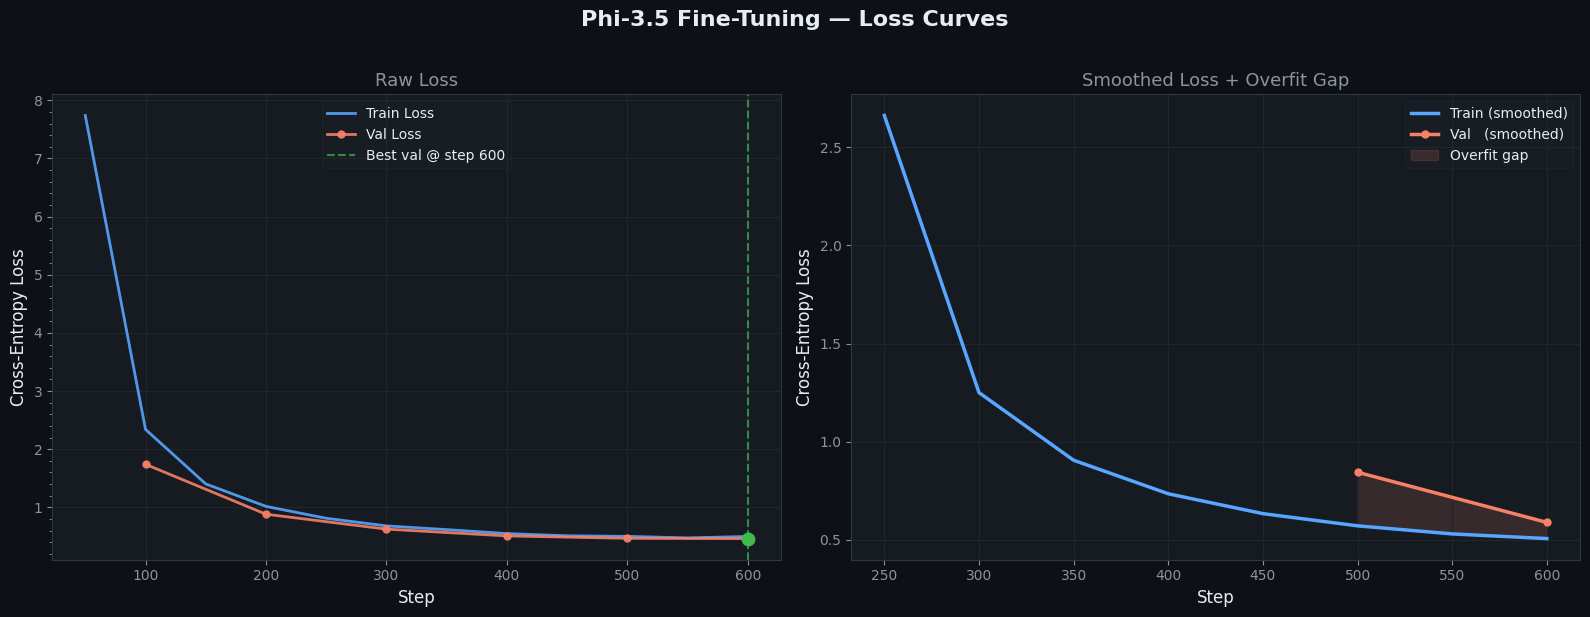

Saved → /kaggle/working/phi-3.5-assistify-finetuned/loss_curves.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "text.color":       "#e6edf3",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.8,
    "font.family":      "DejaVu Sans",
})

train_s = loss_cb.train_steps
train_l = loss_cb.train_losses
eval_s  = loss_cb.eval_steps
eval_l  = loss_cb.eval_losses

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Phi-3.5 Fine-Tuning — Loss Curves",
    fontsize=16, fontweight="bold", color="#e6edf3", y=1.02
)


ax = axes[0]
ax.plot(train_s, train_l, color="#58a6ff", lw=2, label="Train Loss", alpha=0.9)
ax.plot(eval_s,  eval_l,  color="#f78166", lw=2, label="Val Loss",   alpha=0.9,
        marker="o", markersize=5)

if train_l:
    best_val_step = eval_s[np.argmin(eval_l)]
    best_val_loss = min(eval_l)
    ax.axvline(best_val_step, color="#3fb950", lw=1.5, ls="--", alpha=0.7,
               label=f"Best val @ step {best_val_step}")
    ax.scatter([best_val_step], [best_val_loss],
               color="#3fb950", zorder=5, s=80)

ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("Raw Loss", fontsize=13, color="#8b949e")
ax.legend(framealpha=0.2, facecolor="#21262d", edgecolor="#30363d")
ax.grid(True)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())


ax2 = axes[1]

def smooth(vals, win=5):
    if len(vals) < win:
        return vals
    return np.convolve(vals, np.ones(win)/win, mode='valid')

sm_train = smooth(train_l)
sm_eval  = smooth(eval_l)
sm_train_steps = train_s[len(train_s)-len(sm_train):]
sm_eval_steps  = eval_s [len(eval_s) -len(sm_eval) :]

ax2.plot(sm_train_steps, sm_train, color="#58a6ff", lw=2.5, label="Train (smoothed)")
ax2.plot(sm_eval_steps,  sm_eval,  color="#f78166", lw=2.5, label="Val   (smoothed)",
         marker="o", markersize=5)

# overfitting gap shading
if len(sm_eval_steps) > 0 and len(sm_train_steps) > 0:
    common_steps = sorted(set(sm_train_steps) & set(sm_eval_steps))
    if common_steps:
        t_map = dict(zip(sm_train_steps, sm_train))
        e_map = dict(zip(sm_eval_steps,  sm_eval))
        t_vals = [t_map[s] for s in common_steps]
        e_vals = [e_map[s] for s in common_steps]
        ax2.fill_between(common_steps, t_vals, e_vals,
                         where=[e > t for e, t in zip(e_vals, t_vals)],
                         alpha=0.15, color="#f78166", label="Overfit gap")

ax2.set_xlabel("Step", fontsize=12)
ax2.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax2.set_title("Smoothed Loss + Overfit Gap", fontsize=13, color="#8b949e")
ax2.legend(framealpha=0.2, facecolor="#21262d", edgecolor="#30363d")
ax2.grid(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_curves.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {OUTPUT_DIR}/loss_curves.png")


## 10. Save Model

In [12]:
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to: {OUTPUT_DIR}")


Model saved to: /kaggle/working/phi-3.5-assistify-finetuned


## 11. Comprehensive Model Evaluation

In [ ]:
import time, math, re
import numpy as np
import torch
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from collections import defaultdict

def chat(text: str, max_new_tokens: int = 150) -> tuple[str, float]:
    """Returns (response_text, latency_seconds)"""
    prompt = (
        f"<|system|>\n{SYSTEM_PROMPT}\n"
        f"<|user|>\n{text}\n"
        f"<|assistant|>\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    t0 = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            past_key_values=None, 
            use_cache=False,     
        )
    latency = time.time() - t0
    
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    decoded = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return decoded.strip(), latency

print("=" * 60)
print("  11-A  |  Perplexity on Eval Set")
print("=" * 60)

model.eval()
total_loss, total_tokens = 0.0, 0

for ex in eval_dataset.select(range(min(50, len(eval_dataset)))):
    enc = tokenizer(ex["text"], return_tensors="pt",
                    truncation=True, max_length=MAX_SEQ_LEN).to(model.device)
    with torch.no_grad():
        out = model(**enc, labels=enc["input_ids"])
    n_toks = enc["input_ids"].ne(tokenizer.pad_token_id).sum().item()
    total_loss   += out.loss.item() * n_toks
    total_tokens += n_toks

avg_loss   = total_loss / total_tokens
perplexity = math.exp(avg_loss)
print(f"  Avg cross-entropy loss : {avg_loss:.4f}")
print(f"  Perplexity             : {perplexity:.2f}")
print()



print("=" * 60)
print("  11-B  |  ROUGE-L & BLEU")
print("=" * 60)

scorer   = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
sf       = SmoothingFunction().method1
r1s, r2s, rLs, bleus, lats = [], [], [], [], []
sample   = eval_dataset.select(range(min(40, len(eval_dataset))))

for ex in sample:
    parts     = ex["text"].split("<|assistant|>")
    if len(parts) < 2:
        continue
    user_part = parts[0]
    ref_text  = parts[1].replace("<|end|>", "").strip()

    # extract user input from formatted prompt
    user_input = user_part.split("<|user|>")[-1].strip()
    pred_text, lat = chat(user_input)
    lats.append(lat)

    scores = scorer.score(ref_text, pred_text)
    r1s.append(scores["rouge1"].fmeasure)
    r2s.append(scores["rouge2"].fmeasure)
    rLs.append(scores["rougeL"].fmeasure)

    ref_tok  = ref_text.split()
    pred_tok = pred_text.split()
    bleu_s   = sentence_bleu([ref_tok], pred_tok, smoothing_function=sf)
    bleus.append(bleu_s)

print(f"  ROUGE-1  : {np.mean(r1s):.4f}")
print(f"  ROUGE-2  : {np.mean(r2s):.4f}")
print(f"  ROUGE-L  : {np.mean(rLs):.4f}")
print(f"  BLEU     : {np.mean(bleus):.4f}")
print(f"  Avg latency : {np.mean(lats)*1000:.0f} ms/sample")
print()


print("=" * 60)
print("  11-C  |  Quality by Intent")
print("=" * 60)

intent_scores = defaultdict(list)
eval_with_intent = eval_dataset.select(range(min(60, len(eval_dataset))))

for ex in eval_with_intent:
    parts = ex["text"].split("<|assistant|>")
    if len(parts) < 2:
        continue
    ref_text   = parts[1].replace("<|end|>", "").strip()
    user_input = parts[0].split("<|user|>")[-1].strip()
    intent     = ex.get("intent", "unknown")
    pred_text, _ = chat(user_input)
    sc = scorer.score(ref_text, pred_text)["rougeL"].fmeasure
    intent_scores[intent].append(sc)

print(f"  {'Intent':<35}  Avg ROUGE-L   Samples")
print(f"  {'-'*35}  {'-'*11}   {'-'*7}")
for intent, scores_list in sorted(intent_scores.items(),
                                   key=lambda x: -np.mean(x[1])):
    print(f"  {intent:<35}  {np.mean(scores_list):.4f}       {len(scores_list)}")
print()


print("=" * 60)
print("  11-D  |  Language Detection Accuracy")
print("=" * 60)

def is_arabic(text):
    return bool(re.search(r'[\u0600-\u06FF]', text))

lang_tests = [
    ("اطلبلي weight scale دلوقتي",           True),
    ("How can I return my blood pressure monitor?", False),
    ("عايز أعرف سعر جهاز الأكسجين",         True),
    ("What is the price of a pulse oximeter?",     False),
    ("ممكن تساعدني في الطلب؟",               True),
    ("Do you deliver to Cairo?",               False),
]

correct = 0
for text, expect_ar in lang_tests:
    pred, _ = chat(text)
    got_ar  = is_arabic(pred)
    ok      = (got_ar == expect_ar)
    correct += ok
    lang_lbl = "Arabic" if expect_ar else "English"
    got_lbl  = "Arabic" if got_ar else "English"
    status   = "✓" if ok else "✗"
    print(f"  {status}  [{lang_lbl}] input → [{got_lbl}] response")
    print(f"     Input   : {text[:60]}")
    print(f"     Response: {pred[:80]}")

acc = correct / len(lang_tests) * 100
print(f"\n  Language accuracy: {correct}/{len(lang_tests)} = {acc:.1f}%")


print()
print("╔" + "═"*58 + "╗")
print("║" + " EVALUATION SUMMARY ".center(58) + "║")
print("╠" + "═"*58 + "╣")
print(f"║  Perplexity         : {perplexity:>8.2f}" + " "*22 + "║")
print(f"║  ROUGE-L            : {np.mean(rLs):>8.4f}" + " "*22 + "║")
print(f"║  BLEU               : {np.mean(bleus):>8.4f}" + " "*22 + "║")
print(f"║  Lang accuracy      : {acc:>7.1f}%" + " "*22 + "║")
print(f"║  Avg latency        : {np.mean(lats)*1000:>6.0f} ms" + " "*21 + "║")
print("╚" + "═"*58 + "╝")


  11-A  |  Perplexity on Eval Set


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

  Avg cross-entropy loss : 0.4266
  Perplexity             : 1.53

  11-B  |  ROUGE-L & BLEU
  ROUGE-1  : 0.1651
  ROUGE-2  : 0.1250
  ROUGE-L  : 0.1596
  BLEU     : 0.1861
  Avg latency : 23952 ms/sample

  11-C  |  Quality by Intent
  Intent                               Avg ROUGE-L   Samples
  -----------------------------------  -----------   -------
  return                               0.5294       4
  product_details                      0.4571       5
  confirmation                         0.3333       3
  goodbye                              0.2381       5
  recommendation_request               0.2276       5
  memory_check                         0.0928       3
  inquiry                              0.0813       7
  support                              0.0813       6
  introduce_name                       0.0714       2
  purchase                             0.0625       3
  product_search                       0.0417       2
  payment                              0.0323    

## 12. Evaluation Metrics — Visualisation

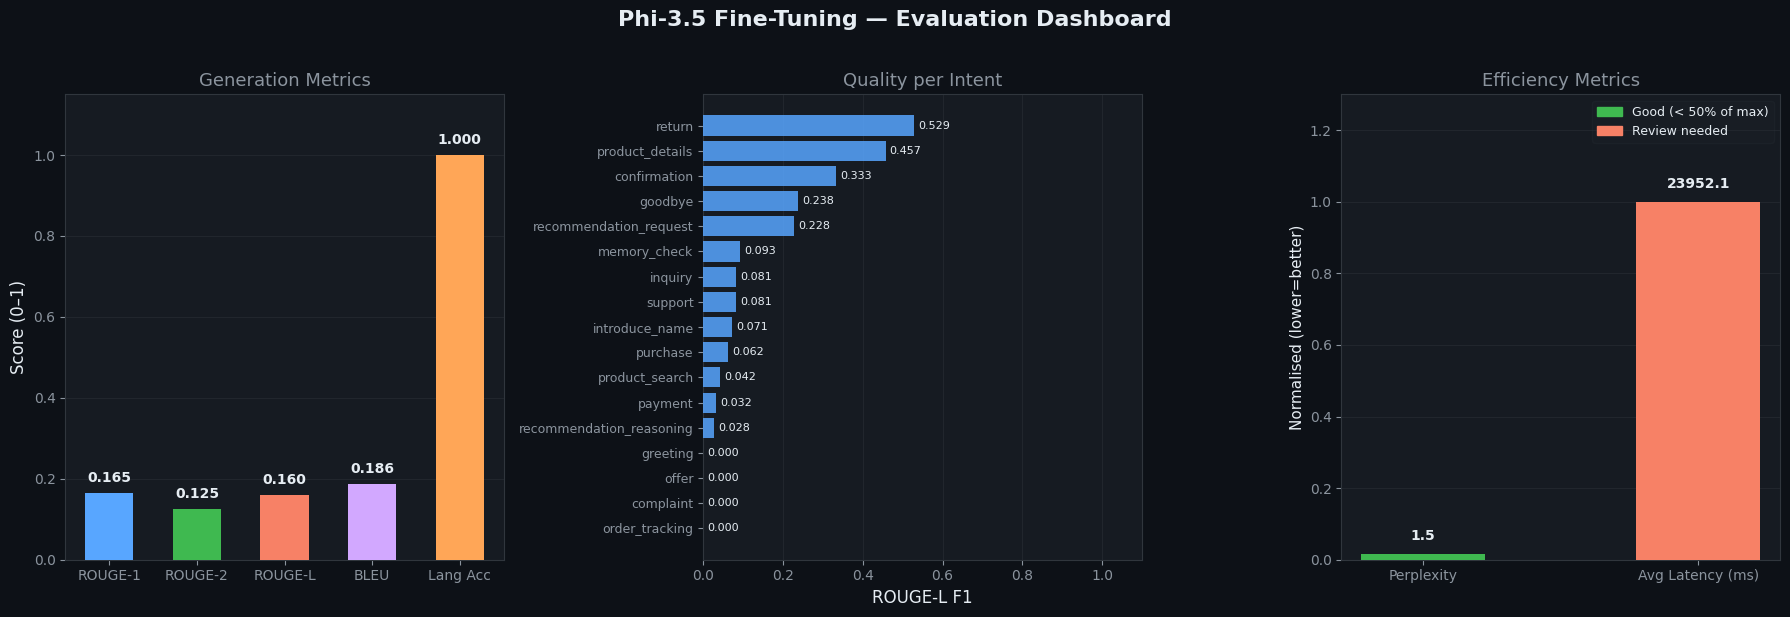

Saved → /kaggle/working/phi-3.5-assistify-finetuned/eval_dashboard.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "text.color":       "#e6edf3",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.8,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Phi-3.5 Fine-Tuning — Evaluation Dashboard",
             fontsize=16, fontweight="bold", color="#e6edf3", y=1.02)

COLORS = ["#58a6ff", "#3fb950", "#f78166", "#d2a8ff", "#ffa657"]


ax = axes[0]
metrics = {
    "ROUGE-1": np.mean(r1s),
    "ROUGE-2": np.mean(r2s),
    "ROUGE-L": np.mean(rLs),
    "BLEU":    np.mean(bleus),
    "Lang Acc": acc / 100,
}
bars = ax.bar(metrics.keys(), metrics.values(),
              color=COLORS[:len(metrics)], width=0.55, zorder=3)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score (0–1)", fontsize=12)
ax.set_title("Generation Metrics", fontsize=13, color="#8b949e")
ax.grid(True, axis="y")
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10,
            color="#e6edf3", fontweight="bold")

ax2 = axes[1]
if intent_scores:
    int_names  = list(intent_scores.keys())
    int_vals   = [np.mean(v) for v in intent_scores.values()]
    sorted_pairs = sorted(zip(int_names, int_vals), key=lambda x: x[1])
    int_names, int_vals = zip(*sorted_pairs)

    bars2 = ax2.barh(range(len(int_names)), int_vals,
                     color="#58a6ff", alpha=0.85, zorder=3)
    ax2.set_yticks(range(len(int_names)))
    ax2.set_yticklabels([n[:30] for n in int_names], fontsize=9)
    ax2.set_xlim(0, 1.1)
    ax2.set_xlabel("ROUGE-L F1", fontsize=12)
    ax2.set_title("Quality per Intent", fontsize=13, color="#8b949e")
    ax2.grid(True, axis="x")
    for bar, val in zip(bars2, int_vals):
        ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=8, color="#e6edf3")


ax3 = axes[2]
labels   = ["Perplexity", "Avg Latency (ms)"]
raw_vals = [perplexity, np.mean(lats)*1000]
norm     = [min(perplexity/100, 1.0), min(np.mean(lats)*1000/2000, 1.0)]
colors3  = ["#f78166" if v > 0.5 else "#3fb950" for v in norm]
bars3 = ax3.bar(labels, norm, color=colors3, width=0.45, zorder=3)
ax3.set_ylim(0, 1.3)
ax3.set_ylabel("Normalised (lower=better)", fontsize=11)
ax3.set_title("Efficiency Metrics", fontsize=13, color="#8b949e")
ax3.grid(True, axis="y")
for bar, raw, nrm in zip(bars3, raw_vals, norm):
    ax3.text(bar.get_x() + bar.get_width()/2, nrm + 0.03,
             f"{raw:.1f}", ha="center", va="bottom",
             fontsize=10, color="#e6edf3", fontweight="bold")

note = mpatches.Patch(color="#3fb950", label="Good (< 50% of max)")
warn = mpatches.Patch(color="#f78166", label="Review needed")
ax3.legend(handles=[note, warn], framealpha=0.2, facecolor="#21262d",
           edgecolor="#30363d", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eval_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {OUTPUT_DIR}/eval_dashboard.png")


## 13. Quick Inference Test

In [15]:
test_cases = [
    "اطلبلي weight scale دلوقتي",
    "Do you remember my previous order for urine analyzer?",
    "Good morning Mariam please",
    "How can I return my blood pressure monitor?",
    "عايز أعرف سعر جهاز الأكسجين",
]

print(" Inference Tests:")
print("-" * 60)
for text in test_cases:
    response, lat = chat(text)
    print(f"Input    : {text}")
    print(f"Response : {response}")
    print(f"Latency  : {lat*1000:.0f} ms")
    print()


 Inference Tests:
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

Input    : اطلبلي weight scale دلوقتي
Response : ممتاز! هكمل معاك على طول. في أي تفاصيل تانية؟
Latency  : 24746 ms

Input    : Do you remember my previous order for urine analyzer?
Response : I'll search that for you! Do you have a specific budget or features in mind?
Latency  : 9980 ms

Input    : Good morning Mariam please
Response : Great! I'll proceed right away. Anything else you'd like to add?
Latency  : 10386 ms

Input    : How can I return my blood pressure monitor?
Response : You can return products within 14 days of delivery. Please share your order number and reason for return.
Latency  : 11460 ms

Input    : عايز أعرف سعر جهاز الأكسجين
Response : ممتاز! هكمل معاك على طول. في أي تفاصيل تانية؟
Latency  : 26097 ms

